# Notebook 08 — Subsurface H Energy & ΔH_sol
## Hastelloy N | Hydrogen Interaction Study

---

> **Guiding Principle:** Start from the smallest possible piece. Build confidence at each step before adding complexity.

**What this notebook computes:**
- Energy of H at every distinct subsurface interstitial site (octahedral and tetrahedral)
- Heat of solution ΔH_sol = E(slab+H_sub) − E(clean slab) − ½E(H₂)
- Most stable subsurface site and its depth profile
- ΔH_sol feeds directly into the Sieverts constant K_S in NB13

**Inputs (from logs — no hardcoding):**
- `structures/hastelloy_n_slab_relaxed.lammps` — relaxed clean slab (NB04)
- `results/ads_clean_slab.log` — E(clean slab, minimized) (NB05)
- `results/ads_h2_gas.log` — E(H₂ gas) (NB05)

**Outputs:**
- `results/subsurface_energies.txt` — ΔH_sol at all sites
- `results/notebook08_subsurface.png` — energy vs depth profile
- `structures/h_subsurface_best.lammps` — most stable subsurface configuration

**Next notebook:** `09_surface_to_subsurface_neb.ipynb`

---
**Key parameters:**
```
Sites       : octahedral (O) and tetrahedral (T) interstices, layers 1–4
Formula     : ΔH_sol = E(slab+H_sub) − E(clean slab) − ½E(H₂)
Method      : CG minimization (same as NB05)
Frozen      : bottom 2 layers (same as NB04)
```
---
**Citation style:** ACS — inline [N], full list in Section 5.

---
## 1. Theory & Background
---

### 1.1 Heat of Solution ΔH_sol

The heat of solution quantifies the energy for H to move from the gas phase into the bulk metal [1,2]:

$$\Delta H_{sol} = E(\text{slab} + H_{sub}) - E(\text{clean slab}) - \frac{1}{2}E(H_2)$$

- **ΔH_sol < 0** — exothermic solution, H prefers to be inside the metal (endothermic for H₂ dissociation dominates)
- **ΔH_sol > 0** — endothermic solution, H prefers the gas phase over bulk

For Ni-based alloys, ΔH_sol is typically +0.1 to +0.4 eV (endothermic), making H solubility low but non-zero [2,3]. The Sieverts constant K_S relates to ΔH_sol via:

$$K_S = A \exp\left(-\frac{\Delta H_{sol}}{k_B T}\right)$$

and the permeability P = D × K_S. Both ΔH_sol and D (from NB11-12) are needed for the final permeability.

**Key references:** [1,2,3]

### 1.2 Interstitial Sites in FCC

In an FCC metal, H occupies interstitial sites rather than substitutional positions [1,4]:

| Site | Coordination | Count per unit cell | Typical H preference |
|------|-------------|--------------------|-----------------------|
| **Octahedral (O)** | 6 metal atoms | 1 per FCC atom | Preferred in Ni, Pd |
| **Tetrahedral (T)** | 4 metal atoms | 2 per FCC atom | Less stable in Ni |

In our 3×4×6 slab (72 atoms), layers 1-4 from the surface contain the subsurface sites of interest. Layer 5-6 approach bulk behavior.

**FCC octahedral site position** (relative to corner atom at origin):
- Body center: (½, ½, ½) in fractional coords
- Edge centers: (½, 0, 0), (0, ½, 0), (0, 0, ½)

**FCC tetrahedral site position:**
- (¼, ¼, ¼) and equivalent positions

**Key references:** [1,4]

### 1.3 Strategy

Rather than enumerate all possible interstitial positions analytically (error-prone for an alloy slab), we use a **geometric approach**:

1. For each subsurface layer pair (layer 1-2, 2-3, 3-4, 4-5), find the centroid of each O and T site from the actual atom positions after relaxation
2. Place H at each candidate site
3. Minimize with the same frozen-layer protocol as NB05
4. Compute ΔH_sol for each
5. Rank by ΔH_sol — the most stable site(s) feed into NB09 NEB

This approach handles the chemical disorder of Hastelloy N automatically — different local environments near Mo, Cr, Fe give different ΔH_sol values for nominally equivalent crystallographic sites.

---
## 2. Execution Strategy
---

### What We Are Doing in This Notebook

```
3.1  Imports, parameters — read E(clean slab) and E(H₂) from NB05 logs
3.2  Find subsurface interstitial sites geometrically from relaxed slab
3.3  Write LAMMPS minimization scripts (one per site)
3.4  Submit all jobs in batches of 8
3.5  Parse logs — compute ΔH_sol for each site
3.6  Plot energy vs depth profile
3.7  Save best subsurface structure for NEB input (NB09)
3.8  Decision cell
```

---
## 3. Code
---

### 3.1 — Imports, Parameters & Read Previous Results

In [4]:
import numpy as np
import os
import subprocess
import shutil
import matplotlib.pyplot as plt
from ase.io import read
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

import ase
print(f'ASE version : {ase.__version__}')
print(f'NumPy       : {np.__version__}')

# ═══════════════════════════════════════════════════════════
# YOUR SYSTEM PATHS
# ═══════════════════════════════════════════════════════════
LAMMPS_CMD   = '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap/lmp'
MACE_MODEL   = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model-mliap_lammps.pt'
KOKKOS_FLAGS = ['-k', 'on', 'g', '1', '-sf', 'kk',
                '-pk', 'kokkos', 'newton', 'on', 'neigh', 'half']
SLURM_CONFIG = {
    'partition'     : 'multigpu',
    'ntasks'        : 1,
    'cpus_per_task' : 8,
    'gpu'           : 'a100:1',
    'time'          : '02:00:00',
    'conda_env'     : 'mace-lammps',
    'cuda_version'  : '12.3.0',
    'openmpi_ver'   : '4.1.6',
    'ld_paths'      : [
        '/shared/EL9/explorer/cuda/12.3.0/lib64/stubs',
        '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap',
        '/home/akinyemi.az/miniforge3/envs/mace-lammps/lib',
    ]
}

# ── Fixed constants ──────────────────────────────────────────
ELEM_STR    = 'Al B C Cr Fe Mo Ni H'
PAIR_STYLE  = 'mliap unified'
PAIR_SUFFIX = '0'
E2T = {'Al':1,'B':2,'C':3,'Cr':4,'Fe':5,'Mo':6,'Ni':7,'H':8}
MASSES = {
    1:(26.9815,'Al'), 2:(10.8110,'B'),  3:(12.0110,'C'),
    4:(51.9961,'Cr'), 5:(55.8450,'Fe'), 6:(95.9600,'Mo'),
    7:(58.6934,'Ni'), 8:( 1.0080,'H'),
}
Z_FREEZE_CUTOFF = 18.10  # Å — bottom 2 layers (NB04)

# ── Minimization settings (same as NB05) ────────────────────
ETOL    = 0
FTOL    = 1e-6
MAXITER = 10000
MAXEVAL = 100000

# ── File paths ───────────────────────────────────────────────
# SLAB_RELAXED = 'structures/notebook04/hastelloy_n_slab_relaxed.lammps'
# CORRECT — uses re-minimized slab (same geometry as E_clean reference)
SLAB_RELAXED = 'structures/notebook05/clean_slab_reminimized.lammps'

for d in ['structures/notebook08', 'results/notebook08', 'lammps_scripts/notebook08', 'slurm_scripts/notebook08']:
    os.makedirs(d, exist_ok=True)

# ── Helper: parse ENERGY_RESULTS block ───────────────────────
def parse_energy_log(logfile):
    results = {}
    if not os.path.exists(logfile):
        return None
    with open(logfile) as f:
        for line in f:
            line = line.strip()
            for key in ['pe_final_eV', 'fmax_eV_per_Ang', 'natoms']:
                if key in line and ':' in line:
                    try:
                        results[key] = float(line.split(':')[1].strip())
                    except:
                        pass
    return results if results else None

# ── Read reference energies from NB05 logs — no hardcoding ──
print('Reading reference energies from NB05 logs...')

res_clean = parse_energy_log('results/notebook05/ads_clean_slab.log')
if res_clean:
    E_CLEAN_SLAB = res_clean['pe_final_eV']
    print(f'E(clean slab) = {E_CLEAN_SLAB:.6f} eV  [ads_clean_slab.log]')
else:
    raise FileNotFoundError('results/ads_clean_slab.log not found. Complete NB05 first.')

res_h2 = parse_energy_log('results/notebook05/ads_h2_gas.log')
if res_h2:
    E_H2_GAS = res_h2['pe_final_eV']
    print(f'E(H₂ gas)     = {E_H2_GAS:.6f} eV  [ads_h2_gas.log]')
else:
    raise FileNotFoundError('results/notebook05/ads_h2_gas.log not found. Complete NB05 first.')

# ── Load relaxed slab ─────────────────────────────────────────
slab   = read(SLAB_RELAXED, format='lammps-data', style='atomic')
pos    = slab.get_positions()
syms   = np.array(slab.get_chemical_symbols())
L      = slab.cell.lengths()
z_surf = pos[:, 2].max()

print(f'\nSlab: {len(slab)} atoms, cell = {L[0]:.4f} × {L[1]:.4f} × {L[2]:.4f} Å')
print(f'z_surf = {z_surf:.4f} Å')
print(f'E(clean slab) = {E_CLEAN_SLAB:.6f} eV')
print(f'1/2E(H₂)        = {0.5*E_H2_GAS:.6f} eV')

ASE version : 3.27.0
NumPy       : 2.4.3
Reading reference energies from NB05 logs...
E(clean slab) = -2391.342254 eV  [ads_clean_slab.log]
E(H₂ gas)     = -6.790499 eV  [ads_h2_gas.log]

Slab: 360 atoms, cell = 12.6484 × 13.1446 × 52.7202 Å
z_surf = 37.8166 Å
E(clean slab) = -2391.342254 eV
1/2E(H₂)        = -3.395250 eV


### 3.2 — Find Subsurface Interstitial Sites

> Geometric detection from relaxed atom positions. Octahedral sites = centres of 6-atom octahedra. Tetrahedral sites = centres of 4-atom tetrahedra. Both filtered to subsurface layers only.

In [5]:
# ─────────────────────────────────────────────────────────────
# Find subsurface interstitial sites from relaxed slab geometry
# Strategy: for each atom, find its FCC nearest neighbours,
# then compute O and T site positions from those neighbours.
# Filter to subsurface region (between layer 1 and layer 5).
# Refs: FCC interstitials [1,4]
# ─────────────────────────────────────────────────────────────

NN_CUTOFF = 3.2   # Å — nearest-neighbour cutoff (a0/√2 ≈ 2.53 Å, use generous cutoff)
MIN_SITE_SEP = 0.5  # Å — merge sites closer than this

# Layer analysis — identify subsurface z range
# Sort unique z values to identify layers
# z_vals   = np.sort(np.unique(np.round(pos[:, 2], 1)))
# z_layers = [z_vals[0]]  # start with bottom layer
# for z in z_vals[1:]:
#     if z - z_layers[-1] > 0.5:  # new layer if >0.5 Å gap
#         z_layers.append(z)
z_vals   = np.sort(np.unique(np.round(pos[:, 2], 0)))  # round to 1 Å for alloy slab
z_layers = [z_vals[0]]
for z in z_vals[1:]:
    if z - z_layers[-1] > 1.2:   # 1.2 Å gap — needed for alloy (Mo/Ni size mismatch)
        z_layers.append(z)

        
print(f'Identified {len(z_layers)} layers:')
for i, z in enumerate(z_layers):
    n_atoms = np.sum(np.abs(pos[:, 2] - z) < 0.5)
    print(f'  Layer {i+1:2d}: z = {z:.3f} Å  ({n_atoms} atoms)')

# Subsurface region: between surface layer and 4 layers deep
# Layer indexing from top: z_layers[-1] = top surface
z_layers_from_top = z_layers[::-1]  # [surface, sub1, sub2, sub3, sub4, ...]
Z_SUB_HI = z_layers_from_top[0] - 0.3   # just below surface
# Z_SUB_LO = z_layers_from_top[4] if len(z_layers_from_top) > 4 else z_layers_from_top[-1]
# Z_SUB_LO -= 0.5
Z_SUB_LO = z_layers_from_top[2] - 0.5  # 2 layers deep maximum

print(f'\nSubsurface region: {Z_SUB_LO:.3f} to {Z_SUB_HI:.3f} Å')
print(f'(layers 1-4 from surface)')

# ── Find octahedral sites ─────────────────────────────────────
# O site = centre of 6 atoms forming octahedron
# Approximation: midpoint between all pairs of atoms at NN distance,
# then keep only those with 6+ neighbours within NN_CUTOFF

# def find_interstices(positions, cell_lengths, z_lo, z_hi, nn_cut, min_sep):
#     """
#     Find candidate interstitial sites by:
#     1. Computing midpoints between all near-neighbour pairs
#     2. For each midpoint, count how many atoms are within nn_cut
#     3. O sites: 6 neighbours (octahedral coordination)
#     4. T sites: 4 neighbours (tetrahedral coordination)
#     5. Filter to z range and remove duplicates
#     """
#     Lx, Ly = cell_lengths[0], cell_lengths[1]
#     sub_mask = (positions[:, 2] > z_lo) & (positions[:, 2] < z_hi + 2.0)
#     sub_pos  = positions[sub_mask]

#     candidates = []
#     for i in range(len(sub_pos)):
#         for j in range(i+1, len(sub_pos)):
#             dx = sub_pos[j, 0] - sub_pos[i, 0]
#             dy = sub_pos[j, 1] - sub_pos[i, 1]
#             dz = sub_pos[j, 2] - sub_pos[i, 2]
#             # Minimum image convention for x and y
#             dx -= Lx * round(dx/Lx)
#             dy -= Ly * round(dy/Ly)
#             d = np.sqrt(dx**2 + dy**2 + dz**2)
#             if d < nn_cut:
#                 cx = (sub_pos[i, 0] + sub_pos[j, 0]) / 2
#                 cy = (sub_pos[i, 1] + sub_pos[j, 1]) / 2
#                 cz = (sub_pos[i, 2] + sub_pos[j, 2]) / 2
#                 candidates.append([cx % Lx, cy % Ly, cz])

#     # Count neighbours for each candidate
#     o_sites = []
#     t_sites = []
#     for cand in candidates:
#         if cand[2] < z_lo or cand[2] > z_hi:
#             continue
#         n_neighbours = 0
#         for p in positions:
#             dx = p[0] - cand[0]; dx -= Lx*round(dx/Lx)
#             dy = p[1] - cand[1]; dy -= Ly*round(dy/Ly)
#             dz = p[2] - cand[2]
#             if np.sqrt(dx**2+dy**2+dz**2) < nn_cut:
#                 n_neighbours += 1
#         if n_neighbours >= 6:
#             o_sites.append(cand)
#         elif n_neighbours >= 4:
#             t_sites.append(cand)

#     # Remove duplicates within min_sep
#     def deduplicate(sites):
#         unique = []
#         for s in sites:
#             is_dup = False
#             for u in unique:
#                 dx = s[0]-u[0]; dx -= Lx*round(dx/Lx)
#                 dy = s[1]-u[1]; dy -= Ly*round(dy/Ly)
#                 dz = s[2]-u[2]
#                 if np.sqrt(dx**2+dy**2+dz**2) < min_sep:
#                     is_dup = True
#                     break
#             if not is_dup:
#                 unique.append(s)
#         return unique

#     return deduplicate(o_sites), deduplicate(t_sites)

def find_interstices(positions, cell_lengths, z_lo, z_hi, nn_cut, min_sep):
    """
    Find subsurface interstitial sites.
    Key fix: only use midpoints between atoms in DIFFERENT layers
    (dz > 0.8 A) to avoid finding surface hollow sites.
    O sites: 6+ neighbours within nn_cut
    T sites: 4-5 neighbours within nn_cut
    """
    Lx, Ly = cell_lengths[0], cell_lengths[1]
    # Include atoms slightly above z_hi to find sites just below surface
    sub_mask = (positions[:, 2] > z_lo) & (positions[:, 2] < z_hi + 2.5)
    sub_pos  = positions[sub_mask]

    candidates = []
    for i in range(len(sub_pos)):
        for j in range(i+1, len(sub_pos)):
            dx = sub_pos[j, 0] - sub_pos[i, 0]
            dy = sub_pos[j, 1] - sub_pos[i, 1]
            dz = sub_pos[j, 2] - sub_pos[i, 2]
            dx -= Lx * round(dx/Lx)
            dy -= Ly * round(dy/Ly)
            d  = np.sqrt(dx**2 + dy**2 + dz**2)
            # CRITICAL FIX: only interlayer midpoints (dz > 0.8 A)
            # This excludes same-layer pairs which generate surface sites
            if d < nn_cut and abs(dz) > 0.8:
                cx = (sub_pos[i, 0] + sub_pos[j, 0]) / 2
                cy = (sub_pos[i, 1] + sub_pos[j, 1]) / 2
                cz = (sub_pos[i, 2] + sub_pos[j, 2]) / 2
                candidates.append([cx % Lx, cy % Ly, cz])

    # Count neighbours and classify
    o_sites = []
    t_sites = []
    for cand in candidates:
        if cand[2] < z_lo or cand[2] > z_hi:
            continue
        n_neighbours = 0
        for p in positions:
            dx = p[0] - cand[0]; dx -= Lx*round(dx/Lx)
            dy = p[1] - cand[1]; dy -= Ly*round(dy/Ly)
            dz = p[2] - cand[2]
            if np.sqrt(dx**2+dy**2+dz**2) < nn_cut:
                n_neighbours += 1
        if n_neighbours >= 6:
            o_sites.append(cand)
        elif n_neighbours >= 4:
            t_sites.append(cand)

    # Deduplicate with larger separation (1.0 A)
    def deduplicate(sites, sep=1.5):
        unique = []
        for s in sites:
            is_dup = False
            for u in unique:
                dx = s[0]-u[0]; dx -= Lx*round(dx/Lx)
                dy = s[1]-u[1]; dy -= Ly*round(dy/Ly)
                dz = s[2]-u[2]
                if np.sqrt(dx**2+dy**2+dz**2) < sep:
                    is_dup = True
                    break
            if not is_dup:
                unique.append(s)
        return unique

    return deduplicate(o_sites), deduplicate(t_sites)

o_sites, t_sites = find_interstices(
    pos, L, Z_SUB_LO, Z_SUB_HI, NN_CUTOFF, MIN_SITE_SEP
)

# Sort by z (depth from surface)
o_sites.sort(key=lambda s: -s[2])  # surface first
t_sites.sort(key=lambda s: -s[2])

print(f'\nFound {len(o_sites)} octahedral sites')
print(f'Found {len(t_sites)} tetrahedral sites')
print(f'Total: {len(o_sites)+len(t_sites)} subsurface sites to evaluate')

print('\nOctahedral sites:')
for i, s in enumerate(o_sites):
    depth = z_surf - s[2]
    print(f'  O{i:02d}: ({s[0]:.3f}, {s[1]:.3f}, {s[2]:.3f})  depth={depth:.2f} Å')

print('\nTetrahedral sites:')
for i, s in enumerate(t_sites):
    depth = z_surf - s[2]
    print(f'  T{i:02d}: ({s[0]:.3f}, {s[1]:.3f}, {s[2]:.3f})  depth={depth:.2f} Å')

# Combine all sites with labels
ALL_SITES = (
    [(f'O{i:02d}', 'octahedral', s) for i, s in enumerate(o_sites)] +
    [(f'T{i:02d}', 'tetrahedral', s) for i, s in enumerate(t_sites)]
)
print(f'\nTotal sites for minimization: {len(ALL_SITES)}')

Identified 12 layers:
  Layer  1: z = 15.000 Å  (28 atoms)
  Layer  2: z = 17.000 Å  (30 atoms)
  Layer  3: z = 19.000 Å  (29 atoms)
  Layer  4: z = 21.000 Å  (27 atoms)
  Layer  5: z = 23.000 Å  (25 atoms)
  Layer  6: z = 25.000 Å  (26 atoms)
  Layer  7: z = 27.000 Å  (25 atoms)
  Layer  8: z = 29.000 Å  (23 atoms)
  Layer  9: z = 31.000 Å  (21 atoms)
  Layer 10: z = 33.000 Å  (9 atoms)
  Layer 11: z = 36.000 Å  (30 atoms)
  Layer 12: z = 38.000 Å  (28 atoms)

Subsurface region: 32.500 to 37.700 Å
(layers 1-4 from surface)

Found 61 octahedral sites
Found 0 tetrahedral sites
Total: 61 subsurface sites to evaluate

Octahedral sites:
  O00: (2.338, 0.958, 36.761)  depth=1.06 Å
  O01: (11.160, 11.887, 36.742)  depth=1.07 Å
  O02: (1.088, 11.696, 36.737)  depth=1.08 Å
  O03: (12.455, 1.007, 36.718)  depth=1.10 Å
  O04: (8.642, 11.887, 36.711)  depth=1.11 Å
  O05: (9.857, 0.973, 36.699)  depth=1.12 Å
  O06: (5.424, 8.602, 36.697)  depth=1.12 Å
  O07: (11.163, 3.179, 36.692)  depth=1.12 Å
 

### 3.3 — Write LAMMPS Minimization Scripts

In [6]:
# ─────────────────────────────────────────────────────────────
# Write LAMMPS minimization script for slab + 1 H at subsurface site
# Same protocol as NB05 adsorption energy jobs
# ΔH_sol = E(slab+H_sub) - E(clean_slab) - 0.5*E(H2)
# ─────────────────────────────────────────────────────────────

def write_sub_structure(site_label, h_pos):
    """Write slab + 1 H at subsurface position to LAMMPS data file."""
    outfile  = f'structures/notebook08/sub_{site_label}.lammps'
    slab_syms = list(slab.get_chemical_symbols())
    slab_pos  = slab.get_positions()
    all_syms  = slab_syms + ['H']
    h_xyz     = np.array([h_pos[0] % L[0], h_pos[1] % L[1], h_pos[2]])
    all_pos   = np.vstack([slab_pos, h_xyz])

    with open(outfile, 'w') as f:
        f.write(f'# Hastelloy N slab + 1H subsurface at {site_label} — NB08\n\n')
        f.write(f'{len(all_syms)} atoms\n{len(MASSES)} atom types\n\n')
        f.write(f'0.0  {L[0]:.10f}  xlo xhi\n')
        f.write(f'0.0  {L[1]:.10f}  ylo yhi\n')
        f.write(f'0.0  {L[2]:.10f}  zlo zhi\n\n')
        f.write('Masses\n\n')
        for t, (m, el) in MASSES.items():
            f.write(f'{t}  {m}  # {el}\n')
        f.write('\nAtoms # atomic\n\n')
        for i, (sym, p) in enumerate(zip(all_syms, all_pos), 1):
            f.write(f'{i}  {E2T[sym]}  {p[0]:.10f}  {p[1]:.10f}  {p[2]:.10f}\n')
    return outfile

def write_min_script(job_name, input_file, output_file):
    """Write LAMMPS CG minimization script — same as NB05."""
    lines = [
        'units metal', 'atom_style atomic', 'newton on', 'boundary p p f', '',
        f'read_data      {input_file}', '',
        f'pair_style     {PAIR_STYLE} {MACE_MODEL} {PAIR_SUFFIX}',
        f'pair_coeff     * * {ELEM_STR}', '',
        'neighbor       2.0 bin', 'neigh_modify   every 1 delay 0 check yes', '',
        f'region         frozen_reg  block  INF INF  INF INF  EDGE  {Z_FREEZE_CUTOFF}',
        'group          frozen_atoms  region  frozen_reg',
        'group          free_atoms    subtract  all  frozen_atoms',
        'fix            freeze  frozen_atoms  setforce  0.0  0.0  0.0', '',
        'thermo         50', 'thermo_style   custom step pe fmax', '',
        f'minimize       {ETOL}  {FTOL}  {MAXITER}  {MAXEVAL}', '',
        'variable  pe_final  equal  pe',
        'variable  fmax_f    equal  fmax',
        'variable  natoms    equal  atoms', '',
        'print "ENERGY_RESULTS_START"',
        f'print "  job_name         : {job_name}"',
        'print "  pe_final_eV      : ${pe_final}"',
        'print "  fmax_eV_per_Ang  : ${fmax_f}"',
        'print "  natoms           : ${natoms}"',
        'print "ENERGY_RESULTS_END"', '',
        f'write_data     {output_file}',
    ]
    script = '\n'.join(lines) + '\n'
    path   = f'lammps_scripts/notebook08/min_sub_{job_name}.lammps'
    with open(path, 'w') as f:
        f.write(script)
    return path

# Write all structure + script files
job_list = []  # (job_name, site_type, depth, log_file)
sc  = SLURM_CONFIG
kk  = ' '.join(KOKKOS_FLAGS)
ld  = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH'
                for p in sc['ld_paths'])

for site_label, site_type, site_pos in ALL_SITES:
    depth     = z_surf - site_pos[2]
    struct_f  = write_sub_structure(site_label, site_pos)
    out_f     = f'structures/notebook08/sub_{site_label}_relaxed.lammps'
    log_f     = f'results/notebook08/sub_{site_label}.log'
    script_f  = write_min_script(site_label, struct_f, out_f)

    slurm = f"""#!/bin/bash
#SBATCH --job-name=nb08_{site_label}
#SBATCH --ntasks={sc['ntasks']}
#SBATCH --cpus-per-task={sc['cpus_per_task']}
#SBATCH --gres=gpu:{sc['gpu']}
#SBATCH --partition=gpu
#SBATCH --time={sc['time']}
#SBATCH --output=results/notebook08/slurm_sub_{site_label}_%j.out

module load OpenMPI/{sc['openmpi_ver']}
module load cuda/{sc['cuda_version']}
source ~/miniforge3/etc/profile.d/conda.sh
conda activate {sc['conda_env']}
{ld}
cd {os.getcwd()}

{LAMMPS_CMD} {kk} -in {script_f} -log {log_f}
echo "sub_{site_label} done: $(date)"
"""
    sp = f'slurm_scripts/notebook08/run_sub_{site_label}.sh'
    with open(sp, 'w') as f:
        f.write(slurm)
    os.chmod(sp, 0o755)
    job_list.append((site_label, site_type, depth, log_f, out_f))

print(f'Written {len(job_list)} structure + script + SLURM files')
for label, stype, depth, log_f, _ in job_list:
    print(f'  {label:6s} ({stype:12s})  depth={depth:.2f} Å  → {log_f}')

Written 61 structure + script + SLURM files
  O00    (octahedral  )  depth=1.06 Å  → results/notebook08/sub_O00.log
  O01    (octahedral  )  depth=1.07 Å  → results/notebook08/sub_O01.log
  O02    (octahedral  )  depth=1.08 Å  → results/notebook08/sub_O02.log
  O03    (octahedral  )  depth=1.10 Å  → results/notebook08/sub_O03.log
  O04    (octahedral  )  depth=1.11 Å  → results/notebook08/sub_O04.log
  O05    (octahedral  )  depth=1.12 Å  → results/notebook08/sub_O05.log
  O06    (octahedral  )  depth=1.12 Å  → results/notebook08/sub_O06.log
  O07    (octahedral  )  depth=1.12 Å  → results/notebook08/sub_O07.log
  O08    (octahedral  )  depth=1.13 Å  → results/notebook08/sub_O08.log
  O09    (octahedral  )  depth=1.13 Å  → results/notebook08/sub_O09.log
  O10    (octahedral  )  depth=1.14 Å  → results/notebook08/sub_O10.log
  O11    (octahedral  )  depth=1.14 Å  → results/notebook08/sub_O11.log
  O12    (octahedral  )  depth=1.14 Å  → results/notebook08/sub_O12.log
  O13    (octahedral

### 3.4 — Submit All Jobs in Batches of 8

In [15]:
import time

MAX_CONCURRENT = 8
POLL_SECONDS   = 60

def get_running_job_ids(active_ids):
    r = subprocess.run(
        ['squeue', '-u', os.environ.get('USER', 'akinyemi.az'), '-h', '-o', '%i'],
        capture_output=True, text=True)
    queued = set(r.stdout.strip().split())
    return {jid for jid in active_ids if jid in queued}

def wait_for_all(active_ids, poll=POLL_SECONDS):
    while True:
        still_running = get_running_job_ids(active_ids)
        if not still_running:
            return
        print(f'    {len(still_running)} jobs running '
              f'({", ".join(sorted(still_running)[:4])}...)')
        time.sleep(poll)

job_ids = {}
failed  = []
batches = [job_list[i:i+MAX_CONCURRENT]
           for i in range(0, len(job_list), MAX_CONCURRENT)]

print(f'{len(job_list)} jobs → {len(batches)} batches of ≤{MAX_CONCURRENT}')
print()

for b_idx, batch in enumerate(batches):
    print(f'── Batch {b_idx+1}/{len(batches)} ({len(batch)} jobs) ──')
    active = set()

    for site_label, site_type, depth, log_f, out_f in batch:
        sp = f'slurm_scripts/notebook08/run_sub_{site_label}.sh'
        r  = subprocess.run(['sbatch', sp], capture_output=True, text=True)
        if r.returncode == 0:
            jid = r.stdout.strip().split()[-1]
            job_ids[site_label] = jid
            active.add(jid)
            print(f'  ✓ {site_label:6s} ({site_type:12s}) depth={depth:.2f} Å → Job {jid}')
        else:
            failed.append(site_label)
            print(f'  ✗ {site_label:6s} FAILED: {r.stderr.strip()[:60]}')

    print(f'  Waiting for batch {b_idx+1} to finish...')
    wait_for_all(active)
    print(f'  Batch {b_idx+1} complete.\n')

print(f'Submitted: {len(job_ids)}  Failed: {len(failed)}')
if failed:
    print(f'Failed: {failed}')
else:
    print('All jobs done. Run cell 3.5 to compute ΔH_sol.')

61 jobs → 8 batches of ≤8

── Batch 1/8 (8 jobs) ──
  ✓ O00    (octahedral  ) depth=1.06 Å → Job 5805503
  ✓ O01    (octahedral  ) depth=1.07 Å → Job 5805504
  ✓ O02    (octahedral  ) depth=1.08 Å → Job 5805505
  ✓ O03    (octahedral  ) depth=1.10 Å → Job 5805506
  ✓ O04    (octahedral  ) depth=1.11 Å → Job 5805507
  ✓ O05    (octahedral  ) depth=1.12 Å → Job 5805508
  ✓ O06    (octahedral  ) depth=1.12 Å → Job 5805509
  ✓ O07    (octahedral  ) depth=1.12 Å → Job 5805510
  Waiting for batch 1 to finish...
    8 jobs running (5805503, 5805504, 5805505, 5805506...)
    8 jobs running (5805503, 5805504, 5805505, 5805506...)
    8 jobs running (5805503, 5805504, 5805505, 5805506...)
    8 jobs running (5805503, 5805504, 5805505, 5805506...)
    8 jobs running (5805503, 5805504, 5805505, 5805506...)
    8 jobs running (5805503, 5805504, 5805505, 5805506...)
    8 jobs running (5805503, 5805504, 5805505, 5805506...)
    8 jobs running (5805503, 5805504, 5805505, 5805506...)
    8 jobs runnin

In [16]:
# # ─────────────────────────────────────────────────────────────
# # Submit subsurface minimization jobs in batches of 8
# # Each job: 1 A100, ~5-10 min wall time (small system, fast min)
# # ─────────────────────────────────────────────────────────────

# import time

# BATCH_SIZE   = 8
# POLL_SECONDS = 30

# def get_running_job_ids(active_ids):
#     r = subprocess.run(['squeue', '-u', os.environ.get('USER', 'akinyemi.az'),
#                         '-h', '-o', '%i'],
#                        capture_output=True, text=True)
#     queued = set(r.stdout.strip().split())
#     return {jid for jid in active_ids if jid in queued}

# def wait_for_batch(active_ids, poll=POLL_SECONDS):
#     while True:
#         still_running = get_running_job_ids(active_ids)
#         if not still_running:
#             break
#         print(f'    Waiting... {len(still_running)} jobs running '
#               f'({", ".join(sorted(still_running)[:3])}...)')
#         time.sleep(poll)

# job_ids = {}
# batches = [job_list[i:i+BATCH_SIZE] for i in range(0, len(job_list), BATCH_SIZE)]

# print(f'{len(job_list)} jobs → {len(batches)} batches of ≤{BATCH_SIZE}')
# print()

# for b_idx, batch in enumerate(batches):
#     print(f'── Batch {b_idx+1}/{len(batches)} ({len(batch)} jobs) ──')
#     active = set()
#     for site_label, site_type, depth, log_f, out_f in batch:
#         sp = f'slurm_scripts/notebook08/run_sub_{site_label}.sh'
#         result = subprocess.run(['sbatch', sp], capture_output=True, text=True)
#         if result.returncode == 0:
#             jid = result.stdout.strip().split()[-1]
#             job_ids[site_label] = jid
#             active.add(jid)
#             print(f'  ✓ {site_label:6s} ({site_type:12s}) depth={depth:.2f} Å → Job {jid}')
#         else:
#             print(f'  ✗ {site_label:6s} FAILED: {result.stderr.strip()[:50]}')
#     print(f'  Waiting for batch {b_idx+1}...')
#     wait_for_batch(active)
#     print(f'  Batch {b_idx+1} complete.\n')

# print(f'All {len(job_ids)} jobs finished.')
# print('Run cell 3.5 to compute ΔH_sol.')

### 3.5 — Parse Logs and Compute ΔH_sol

> Run after all jobs finish. Safe to rerun after kernel restart.

In [7]:
# ─────────────────────────────────────────────────────────────
# Rebuild job_list — safe after kernel restart
# Compute ΔH_sol = E(slab+H_sub) - E(clean_slab) - 0.5*E(H2)
# Post-relaxation depth check: reject sites where H escaped
# back to the surface during minimization
# ─────────────────────────────────────────────────────────────

# Rebuild from site lists (defined in cell 3.2)
job_list = []
for site_label, site_type, site_pos in ALL_SITES:
    depth  = z_surf - site_pos[2]
    log_f  = f'results/notebook08/sub_{site_label}.log'
    out_f  = f'structures/notebook08/sub_{site_label}_relaxed.lammps'
    job_list.append((site_label, site_type, depth, log_f, out_f))

print(f'Rebuilt job_list: {len(job_list)} entries')
print()

# ── Parse energies ────────────────────────────────────────────
results_sub = []
missing     = []

print(f'{"Site":6s} {"Type":12s} {"Depth_init":>10s} {"Depth_relax":>11s} '
      f'{"E(eV)":>14s} {"ΔH_sol(eV)":>12s} {"fmax":>8s} {"sub?":>6s}')
print('-' * 85)

for site_label, site_type, depth_init, log_f, out_f in job_list:
    res = parse_energy_log(log_f)
    if res and 'pe_final_eV' in res:
        E_sub  = res['pe_final_eV']
        fmax   = res.get('fmax_eV_per_Ang', 0)
        dH_sol = E_sub - E_CLEAN_SLAB - 0.5 * E_H2_GAS

        # ── Post-relaxation depth check ───────────────────────
        # Some sites are not stable subsurface positions — H escapes
        # back to the surface during minimization (depth becomes negative)
        # These are transition states, not stable minima — exclude them
        depth_relaxed = -999.0
        if os.path.exists(out_f):
            try:
                a_rel  = read(out_f, format='lammps-data', style='atomic')
                p_rel  = a_rel.get_positions()
                s_rel  = np.array(a_rel.get_chemical_symbols())
                h_rel  = p_rel[s_rel == 'H']
                z_s    = p_rel[s_rel != 'H', 2].max()
                depth_relaxed = z_s - h_rel[0, 2]
            except Exception:
                pass

        genuinely_sub = depth_relaxed > 0.3   # H must be > 0.3 A below surface
        sub_str = 'YES' if genuinely_sub else 'NO'

        results_sub.append({
            'label'         : site_label,
            'type'          : site_type,
            'depth_init'    : depth_init,
            'depth_relaxed' : depth_relaxed,
            'E_sub'         : E_sub,
            'dH_sol'        : dH_sol,
            'fmax'          : fmax,
            'out_file'      : out_f,
            'genuinely_sub' : genuinely_sub,
        })
        print(f'{site_label:6s} {site_type:12s} {depth_init:>10.3f} '
              f'{depth_relaxed:>11.3f} {E_sub:>14.6f} '
              f'{dH_sol:>12.4f} {fmax:>8.2e} {sub_str:>6s}')
    else:
        missing.append(site_label)
        print(f'{site_label:6s} {site_type:12s} {depth_init:>10.3f} '
              f'{"NOT FOUND":>40s}')

print()

if missing:
    print(f'⚠ {len(missing)} jobs missing: {missing}')

# ── Summary ───────────────────────────────────────────────────
results_sub.sort(key=lambda x: x['dH_sol'])

genuinely_sub = [r for r in results_sub if r['genuinely_sub']]
escaped       = [r for r in results_sub if not r['genuinely_sub']]

print(f'Total sites parsed    : {len(results_sub)}')
print(f'Genuinely subsurface  : {len(genuinely_sub)}  (depth_relaxed > 0.3 A)')
print(f'Escaped to surface    : {len(escaped)}  (H relaxed above surface — not stable)')
print()

if genuinely_sub:
    best = genuinely_sub_by_dist[0]
    print(f'Best genuinely subsurface site: {best["label"]} ({best["type"]})')
    print(f'  Depth (initial)  : {best["depth_init"]:.3f} A')
    print(f'  Depth (relaxed)  : {best["depth_relaxed"]:.3f} A')
    print(f'  ΔH_sol           : {best["dH_sol"]:.4f} eV')
    print(f'  E                : {best["E_sub"]:.6f} eV')
    print()
    thermo = 'exothermic' if best['dH_sol'] < 0 else 'endothermic'
    print(f'  H solution is {thermo} in Hastelloy N')
    if escaped:
        print(f'  Note: {len(escaped)} sites had H escape to surface')
        print(f'  (most negative dH_sol values are surface states, not bulk)')
else:
    print('⚠ No genuinely subsurface sites found.')
    print('  All H atoms escaped to surface during relaxation.')
    print('  Consider deeper sites or different slab geometry.')

Rebuilt job_list: 61 entries

Site   Type         Depth_init Depth_relax          E(eV)   ΔH_sol(eV)     fmax   sub?
-------------------------------------------------------------------------------------
O00    octahedral        1.056       0.373   -2394.401973       0.3355 2.36e-07    YES
O01    octahedral        1.075      -1.028   -2395.324176      -0.5867 2.06e-07     NO
O02    octahedral        1.079       0.481   -2394.721847       0.0157 2.86e-07    YES
O03    octahedral        1.098      -0.967   -2395.306532      -0.5690 2.79e-07     NO
O04    octahedral        1.106       1.020   -2394.423319       0.3142 2.37e-07    YES
O05    octahedral        1.118       1.269   -2394.271628       0.4659 2.41e-07    YES
O06    octahedral        1.119       1.293   -2394.315988       0.4215 2.66e-07    YES
O07    octahedral        1.124      -0.907   -2395.379133      -0.6416 1.96e-07     NO
O08    octahedral        1.127      -0.917   -2395.018788      -0.2813 2.56e-07     NO
O09    octahed

O22    octahedral        1.229       1.234   -2394.242354       0.4951 2.79e-07    YES
O23    octahedral        1.231      -0.918   -2395.525099      -0.7876 2.60e-07     NO
O24    octahedral        1.238      -0.860   -2395.256686      -0.5192 2.02e-07     NO
O25    octahedral        1.242      -0.913   -2395.051233      -0.3137 2.11e-07     NO
O26    octahedral        1.256      -0.917   -2395.156992      -0.4195 3.84e-07     NO
O27    octahedral        1.306       2.080   -2394.407752       0.3298 1.79e-07    YES
O28    octahedral        1.314       1.260   -2394.354461       0.3830 1.96e-07    YES
O29    octahedral        2.787       2.748   -2394.104214       0.6333 2.54e-07    YES
O30    octahedral        2.800       3.538   -2394.392951       0.3446 2.55e-07    YES
O31    octahedral        3.132       3.423   -2394.384013       0.3535 2.77e-07    YES
O32    octahedral        3.140       3.597   -2394.405517       0.3320 2.83e-07    YES
O33    octahedral        3.150       3.276 

In [22]:
# # ─────────────────────────────────────────────────────────────
# # Rebuild job_list — safe after kernel restart
# # Compute ΔH_sol = E(slab+H_sub) - E(clean_slab) - 0.5*E(H2)
# # ─────────────────────────────────────────────────────────────

# # Rebuild from site lists (defined in cell 3.2)
# job_list = []
# for site_label, site_type, site_pos in ALL_SITES:
#     depth  = z_surf - site_pos[2]
#     log_f  = f'results/notebook08/sub_{site_label}.log'
#     out_f  = f'structures/notebook08/sub_{site_label}_relaxed.lammps'
#     job_list.append((site_label, site_type, depth, log_f, out_f))

# print(f'Rebuilt job_list: {len(job_list)} entries')
# print()

# # Parse results
# results_sub = []  # list of dicts
# missing     = []

# print(f'{"Site":6s} {"Type":12s} {"Depth(Å)":>9s} {"E(eV)":>14s} {"ΔH_sol(eV)":>12s} {"fmax":>8s}')
# print('-' * 68)

# for site_label, site_type, depth, log_f, out_f in job_list:
#     res = parse_energy_log(log_f)
#     if res and 'pe_final_eV' in res:
#         E_sub  = res['pe_final_eV']
#         fmax   = res.get('fmax_eV_per_Ang', 0)
#         dH_sol = E_sub - E_CLEAN_SLAB - 0.5 * E_H2_GAS
#         results_sub.append({
#             'label'    : site_label,
#             'type'     : site_type,
#             'depth'    : depth,
#             'E_sub'    : E_sub,
#             'dH_sol'   : dH_sol,
#             'fmax'     : fmax,
#             'out_file' : out_f,
#         })
#         print(f'{site_label:6s} {site_type:12s} {depth:>9.3f} {E_sub:>14.6f} {dH_sol:>12.4f} {fmax:>8.2e}')
#     else:
#         missing.append(site_label)
#         print(f'{site_label:6s} {site_type:12s} {depth:>9.3f} {"NOT FOUND":>14s}')

# print()
# if missing:
#     print(f'⚠ {len(missing)} jobs missing: {missing}')
# else:
#     # Sort and report
#     results_sub.sort(key=lambda x: x['dH_sol'])
#     best = results_sub[0]
#     print(f'Most stable subsurface site: {best["label"]} ({best["type"]})')
#     print(f'  Depth   : {best["depth"]:.3f} Å')
#     print(f'  ΔH_sol  : {best["dH_sol"]:.4f} eV')
#     print(f'  E       : {best["E_sub"]:.6f} eV')
#     print()
#     thermo = 'exothermic' if best['dH_sol'] < 0 else 'endothermic'
#     print(f'  H solution is {thermo} in Hastelloy N')
#     print(f'  (positive ΔH_sol = H prefers gas phase — low bulk solubility)')

### 3.6 — Plot ΔH_sol vs Depth Profile

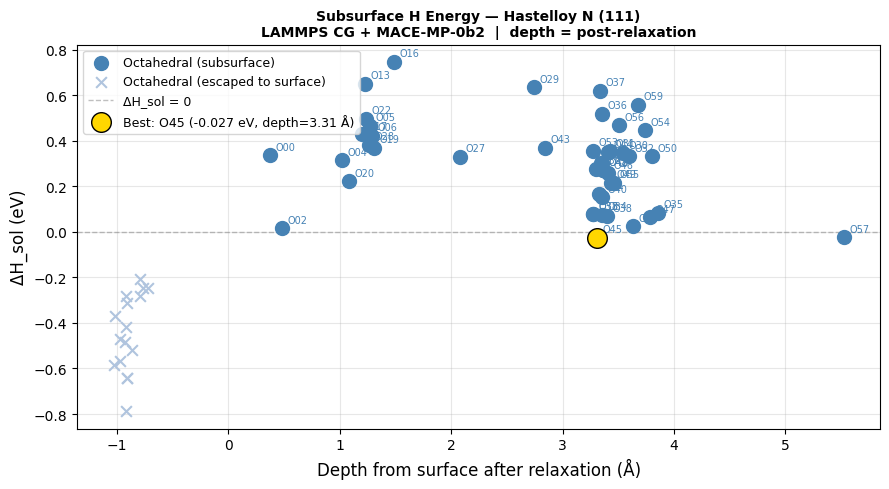

Saved: results/notebook08/notebook08_subsurface.png
  Genuinely subsurface: 45 sites plotted (blue filled)
  Escaped to surface  : 16 sites plotted (blue x)


In [8]:
# ─────────────────────────────────────────────────────────────
# Plot ΔH_sol vs depth from surface
# Uses depth_relaxed (actual post-minimization depth)
# Distinguishes genuinely subsurface sites from escaped sites
# ─────────────────────────────────────────────────────────────

if not results_sub:
    print('No results yet. Run jobs first.')
else:
    # Use depth_relaxed for x-axis — actual H position after minimization
    o_sub  = [(r['depth_relaxed'], r['dH_sol'], r['label'])
               for r in results_sub
               if r['type'] == 'octahedral' and r['genuinely_sub']]
    o_esc  = [(r['depth_relaxed'], r['dH_sol'], r['label'])
               for r in results_sub
               if r['type'] == 'octahedral' and not r['genuinely_sub']]
    t_sub  = [(r['depth_relaxed'], r['dH_sol'], r['label'])
               for r in results_sub
               if r['type'] == 'tetrahedral' and r['genuinely_sub']]

    fig, ax = plt.subplots(figsize=(9, 5))

    if o_sub:
        d, e, l = zip(*sorted(o_sub))
        ax.scatter(d, e, s=100, color='steelblue', zorder=5,
                   label='Octahedral (subsurface)', marker='o')
        for di, ei, li in zip(d, e, l):
            ax.annotate(li, (di, ei), textcoords='offset points',
                        xytext=(4, 4), fontsize=7, color='steelblue')

    if o_esc:
        d, e, l = zip(*sorted(o_esc))
        ax.scatter(d, e, s=60, color='lightsteelblue', zorder=4,
                   label='Octahedral (escaped to surface)', marker='x')

    if t_sub:
        d, e, l = zip(*sorted(t_sub))
        ax.scatter(d, e, s=100, color='tomato', zorder=5,
                   label='Tetrahedral (subsurface)', marker='^')

    ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.5, label='ΔH_sol = 0')

    # Mark best genuinely subsurface site
    best = genuinely_sub_by_dist[0]
    ax.scatter([best['depth_relaxed']], [best['dH_sol']], s=200,
               color='gold', edgecolors='black', zorder=6,
               label=f'Best: {best["label"]} ({best["dH_sol"]:.3f} eV, '
                     f'depth={best["depth_relaxed"]:.2f} Å)')

    ax.set_xlabel('Depth from surface after relaxation (Å)', fontsize=12)
    ax.set_ylabel('ΔH_sol (eV)', fontsize=12)
    ax.set_title('Subsurface H Energy — Hastelloy N (111)\n'
                 'LAMMPS CG + MACE-MP-0b2  |  depth = post-relaxation',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/notebook08/notebook08_subsurface.png', dpi=150,
                bbox_inches='tight')
    plt.show()
    print('Saved: results/notebook08/notebook08_subsurface.png')
    print(f'  Genuinely subsurface: {len(genuinely_sub)} sites plotted (blue filled)')
    print(f'  Escaped to surface  : {len(o_esc)} sites plotted (blue x)')

In [6]:
# # ─────────────────────────────────────────────────────────────
# # Plot ΔH_sol vs depth from surface
# # Shows how subsurface H energy varies with depth and site type
# # ─────────────────────────────────────────────────────────────

# if not results_sub:
#     print('No results yet. Run jobs first.')
# else:
#     o_data = [(r['depth'], r['dH_sol'], r['label'])
#               for r in results_sub if r['type'] == 'octahedral']
#     t_data = [(r['depth'], r['dH_sol'], r['label'])
#               for r in results_sub if r['type'] == 'tetrahedral']

#     fig, ax = plt.subplots(figsize=(9, 5))

#     if o_data:
#         d_o, e_o, l_o = zip(*sorted(o_data))
#         ax.scatter(d_o, e_o, s=100, color='steelblue', zorder=5,
#                    label='Octahedral', marker='o')
#         for d, e, l in zip(d_o, e_o, l_o):
#             ax.annotate(l, (d, e), textcoords='offset points',
#                         xytext=(4, 4), fontsize=7, color='steelblue')

#     if t_data:
#         d_t, e_t, l_t = zip(*sorted(t_data))
#         ax.scatter(d_t, e_t, s=100, color='tomato', zorder=5,
#                    label='Tetrahedral', marker='^')
#         for d, e, l in zip(d_t, e_t, l_t):
#             ax.annotate(l, (d, e), textcoords='offset points',
#                         xytext=(4, -10), fontsize=7, color='tomato')

#     ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.5, label='ΔH_sol = 0')

#     # Mark the best (most stable) site
#     best = results_sub[0]
#     ax.scatter([best['depth']], [best['dH_sol']], s=200,
#                color='gold', edgecolors='black', zorder=6,
#                label=f'Best: {best["label"]} ({best["dH_sol"]:.3f} eV)')

#     ax.set_xlabel('Depth from surface (Å)', fontsize=12)
#     ax.set_ylabel('ΔH_sol (eV)', fontsize=12)
#     ax.set_title('Subsurface H Energy — Hastelloy N (111)', fontsize=12, fontweight='bold')
#     ax.legend(fontsize=9)
#     ax.grid(alpha=0.3)

#     plt.tight_layout()
#     plt.savefig('results/notebook08/notebook08_subsurface.png', dpi=150, bbox_inches='tight')
#     plt.show()
#     print('Saved: results/notebook08/notebook08_subsurface.png')

### 3.7 — Save Results and Best Structure

In [9]:
# ─────────────────────────────────────────────────────────────
# Save ΔH_sol results to file
# Copy best GENUINELY SUBSURFACE structure for NEB09
# Best = closest genuinely subsurface site to the bridge IS
#        (physically correct — H absorbs into nearest site)
#        among sites where H stayed subsurface after relaxation
#        (depth_relaxed > 0.3 A)
# ─────────────────────────────────────────────────────────────

if not results_sub:
    print('No results yet. Run jobs first.')
elif not genuinely_sub:
    print('⚠ No genuinely subsurface sites found.')
    print('  All H atoms escaped to surface — cannot proceed to NB09.')
else:
    # ── Find nearest subsurface site to bridge IS ─────────────
    # Read bridge xy from actual IS structure — no hardcoding
    #is_file = 'structures/notebook06/h_atom_bridge_relaxed.lammps'
    is_file = 'structures/notebook06/h_atom_fcc_hollow_relaxed.lammps'
    if os.path.exists(is_file):
        is_atoms  = read(is_file, format='lammps-data', style='atomic')
        is_pos    = is_atoms.get_positions()
        is_syms   = np.array(is_atoms.get_chemical_symbols())
        bridge_xy = is_pos[is_syms == 'H'][0, :2]
        cell_xy   = np.array([is_atoms.cell.diagonal()[0],
                               is_atoms.cell.diagonal()[1]])
        print(f'Bridge xy from IS: ({bridge_xy[0]:.4f}, {bridge_xy[1]:.4f})')
    else:
        raise FileNotFoundError(
            # 'structures/notebook06/h_atom_bridge_relaxed.lammps not found. '
            'structures/notebook06/h_atom_fcc_hollow_relaxed.lammps'
            'Complete Notebook 06 cell 3.2 first.')

    for r in genuinely_sub:
        if os.path.exists(r['out_file']):
            try:
                a   = read(r['out_file'], format='lammps-data', style='atomic')
                p   = a.get_positions()
                s   = np.array(a.get_chemical_symbols())
                h   = p[s == 'H'][0, :2]
                dxy = h - bridge_xy
                dxy -= np.round(dxy / cell_xy) * cell_xy
                r['dist_to_bridge'] = float(np.linalg.norm(dxy))
            except Exception:
                r['dist_to_bridge'] = 999.0
        else:
            r['dist_to_bridge'] = 999.0

    genuinely_sub_by_dist = sorted(genuinely_sub,
                                    key=lambda r: r['dist_to_bridge'])
    best = genuinely_sub_by_dist[0]

    print(f'Nearest subsurface site to bridge: {best["label"]}  '
          f'xy_dist={best["dist_to_bridge"]:.4f} A  '
          f'depth={best["depth_relaxed"]:.3f} A  '
          f'dH_sol={best["dH_sol"]:.4f} eV')

    # ── Save full results table ───────────────────────────────
    with open('results/notebook08/subsurface_energies.txt', 'w') as f:
        f.write('Hastelloy N (111) Subsurface H Energy — Notebook 08\n')
        f.write('=' * 60 + '\n')
        f.write(f'Method       : LAMMPS CG minimize + MACE-MP-0b2\n')
        f.write(f'Slab         : {len(slab)} atoms  '
                f'[clean_slab_reminimized.lammps]\n')
        f.write(f'E(clean slab): {E_CLEAN_SLAB:.6f} eV  '
                f'[ads_clean_slab.log]\n')
        f.write(f'E(H2 gas)    : {E_H2_GAS:.6f} eV  [ads_h2_gas.log]\n')
        f.write(f'1/2E(H2)     : {0.5*E_H2_GAS:.6f} eV\n')
        f.write(f'Formula      : dH_sol = E(slab+H_sub) - E(clean) - 1/2E(H2)\n\n')
        f.write(f'{"Site":6s} {"Type":12s} {"Depth_init":>10s} '
                f'{"Depth_relax":>11s} {"E(slab+H)(eV)":>16s} '
                f'{"dH_sol(eV)":>12s} {"fmax":>8s} '
                f'{"sub?":>6s} {"dist_bridge":>12s}\n')
        f.write('-' * 95 + '\n')
        for r in results_sub:
            sub_str  = 'YES' if r['genuinely_sub'] else 'NO'
            dist_str = f'{r.get("dist_to_bridge", 999.0):.4f}'
            f.write(f'{r["label"]:6s} {r["type"]:12s} '
                    f'{r["depth_init"]:>10.3f} {r["depth_relaxed"]:>11.3f} '
                    f'{r["E_sub"]:>16.6f} {r["dH_sol"]:>12.4f} '
                    f'{r["fmax"]:>8.2e} {sub_str:>6s} '
                    f'{dist_str:>12s}\n')

        f.write(f'\nNearest subsurface to bridge (NB09 FS): '
                f'{best["label"]} ({best["type"]}) '
                f'depth_relaxed={best["depth_relaxed"]:.3f} A  '
                f'dH_sol={best["dH_sol"]:.4f} eV  '
                f'xy_dist={best["dist_to_bridge"]:.4f} A\n')
        # This line is parsed by NB09 cell 3.1
        f.write(f'Most stable: {best["label"]} ({best["type"]}) '
                f'depth={best["depth_relaxed"]:.3f} A  '
                f'dH_sol={best["dH_sol"]:.4f} eV\n')

    print('Saved: results/notebook08/subsurface_energies.txt')

    # ── Copy best structure for NB09 ──────────────────────────
    if os.path.exists(best['out_file']):
        shutil.copy(best['out_file'],
                    'structures/notebook08/h_subsurface_best.lammps')
        print(f'Saved: structures/notebook08/h_subsurface_best.lammps  '
              f'({best["label"]})')
    else:
        print(f'Warning: {best["out_file"]} not found')

    print()
    print('Summary:')
    print(f'  Sites evaluated        : {len(results_sub)}')
    print(f'  Genuinely subsurface   : {len(genuinely_sub)}')
    print(f'  Escaped to surface     : '
          f'{len([r for r in results_sub if not r["genuinely_sub"]])}')
    print(f'  Best site (NB09 FS)    : {best["label"]} ({best["type"]})')
    print(f'  xy dist to bridge      : {best["dist_to_bridge"]:.4f} A')
    print(f'  Depth (relaxed)        : {best["depth_relaxed"]:.3f} A')
    print(f'  dH_sol                 : {best["dH_sol"]:.4f} eV')
    print(f'  dH_sol range (sub only): '
          f'{genuinely_sub_by_dist[-1]["dH_sol"]:.4f} to '
          f'{genuinely_sub_by_dist[0]["dH_sol"]:.4f} eV')
    print()
    print('NB09 will use:')
    print(f'  IS: structures/notebook06/h_atom_bridge_relaxed.lammps')
    print(f'  FS: structures/notebook08/h_subsurface_best.lammps  '
          f'({best["label"]})')

Bridge xy from IS: (6.0965, 5.1676)
Nearest subsurface site to bridge: O22  xy_dist=1.3007 A  depth=1.234 A  dH_sol=0.4951 eV
Saved: results/notebook08/subsurface_energies.txt
Saved: structures/notebook08/h_subsurface_best.lammps  (O22)

Summary:
  Sites evaluated        : 61
  Genuinely subsurface   : 45
  Escaped to surface     : 16
  Best site (NB09 FS)    : O22 (octahedral)
  xy dist to bridge      : 1.3007 A
  Depth (relaxed)        : 1.234 A
  dH_sol                 : 0.4951 eV
  dH_sol range (sub only): 0.0157 to 0.4951 eV

NB09 will use:
  IS: structures/notebook06/h_atom_bridge_relaxed.lammps
  FS: structures/notebook08/h_subsurface_best.lammps  (O22)


In [10]:
# Quick check after running cell 3.7
print(f'NB09 FS: {best["label"]}')
print(f'  xy_dist to bridge : {best["dist_to_bridge"]:.4f} A')
print(f'  depth (relaxed)   : {best["depth_relaxed"]:.3f} A')
print(f'  dH_sol            : {best["dH_sol"]:.4f} eV')

NB09 FS: O22
  xy_dist to bridge : 1.3007 A
  depth (relaxed)   : 1.234 A
  dH_sol            : 0.4951 eV


In [11]:
# # ─────────────────────────────────────────────────────────────
# # Save ΔH_sol results to file
# # Copy best GENUINELY SUBSURFACE structure for NEB09
# # Best = lowest dH_sol among sites where H stayed subsurface
# #        after relaxation (depth_relaxed > 0.3 A)
# # ─────────────────────────────────────────────────────────────

# if not results_sub:
#     print('No results yet. Run jobs first.')
# elif not genuinely_sub:
#     print('⚠ No genuinely subsurface sites found.')
#     print('  All H atoms escaped to surface — cannot proceed to NB09.')
# else:
#     best = genuinely_sub_by_dist[0]   # lowest dH_sol among genuinely subsurface sites

#     # ── Save full results table ───────────────────────────────
#     with open('results/notebook08/subsurface_energies.txt', 'w') as f:
#         f.write('Hastelloy N (111) Subsurface H Energy — Notebook 08\n')
#         f.write('=' * 60 + '\n')
#         f.write(f'Method       : LAMMPS CG minimize + MACE-MP-0b2\n')
#         f.write(f'Slab         : {len(slab)} atoms  '
#                 f'[clean_slab_reminimized.lammps]\n')
#         f.write(f'E(clean slab): {E_CLEAN_SLAB:.6f} eV  '
#                 f'[ads_clean_slab.log]\n')
#         f.write(f'E(H₂ gas)    : {E_H2_GAS:.6f} eV  [ads_h2_gas.log]\n')
#         f.write(f'½E(H₂)       : {0.5*E_H2_GAS:.6f} eV\n')
#         f.write(f'Formula      : ΔH_sol = E(slab+H_sub) - E(clean) - ½E(H₂)\n\n')
#         f.write(f'{"Site":6s} {"Type":12s} {"Depth_init":>10s} '
#                 f'{"Depth_relax":>11s} {"E(slab+H)(eV)":>16s} '
#                 f'{"ΔH_sol(eV)":>12s} {"fmax":>8s} {"sub?":>6s}\n')
#         f.write('-' * 85 + '\n')
#         for r in results_sub:
#             sub_str = 'YES' if r['genuinely_sub'] else 'NO'
#             f.write(f'{r["label"]:6s} {r["type"]:12s} '
#                     f'{r["depth_init"]:>10.3f} {r["depth_relaxed"]:>11.3f} '
#                     f'{r["E_sub"]:>16.6f} {r["dH_sol"]:>12.4f} '
#                     f'{r["fmax"]:>8.2e} {sub_str:>6s}\n')

#         f.write(f'\nMost stable (genuinely subsurface): '
#                 f'{best["label"]} ({best["type"]}) '
#                 f'depth_relaxed={best["depth_relaxed"]:.3f} Å  '
#                 f'ΔH_sol={best["dH_sol"]:.4f} eV\n')
#         f.write(f'Most stable: {best["label"]} ({best["type"]}) '
#                 f'depth={best["depth_relaxed"]:.3f} Å  '
#                 f'ΔH_sol={best["dH_sol"]:.4f} eV\n')

#     print('Saved: results/notebook08/subsurface_energies.txt')

#     # ── Copy best structure for NB09 ──────────────────────────
#     if os.path.exists(best['out_file']):
#         shutil.copy(best['out_file'],
#                     'structures/notebook08/h_subsurface_best.lammps')
#         print(f'Saved: structures/notebook08/h_subsurface_best.lammps  '
#               f'({best["label"]})')
#     else:
#         print(f'Warning: {best["out_file"]} not found')

#     print()
#     print('Summary:')
#     print(f'  Sites evaluated        : {len(results_sub)}')
#     print(f'  Genuinely subsurface   : {len(genuinely_sub)}')
#     print(f'  Escaped to surface     : '
#           f'{len([r for r in results_sub if not r["genuinely_sub"]])}')
#     print(f'  Best site (NB09 FS)    : {best["label"]} ({best["type"]})')
#     print(f'  Depth (relaxed)        : {best["depth_relaxed"]:.3f} Å')
#     print(f'  ΔH_sol                 : {best["dH_sol"]:.4f} eV')
#     print(f'  ΔH_sol range (sub only): '
#           f'{genuinely_sub[-1]["dH_sol"]:.4f} to '
#           f'{genuinely_sub[0]["dH_sol"]:.4f} eV')
#     print()
#     print('NB09 will use:')
#     print(f'  IS: structures/notebook06/h_atom_bridge_relaxed.lammps')
#     print(f'  FS: structures/notebook08/h_subsurface_best.lammps  '
#           f'({best["label"]})')

In [12]:
# # ─────────────────────────────────────────────────────────────
# # Save ΔH_sol results to file
# # Copy best subsurface structure for NEB input (NB09)
# # ─────────────────────────────────────────────────────────────

# if not results_sub:
#     print('No results yet. Run jobs first.')
# else:
#     # Save full results table
#     with open('results/notebook08/subsurface_energies.txt', 'w') as f:
#         f.write('Hastelloy N (111) Subsurface H Energy — Notebook 08\n')
#         f.write('=' * 60 + '\n')
#         f.write(f'Method       : LAMMPS CG minimize + MACE-MP-0b2\n')
#         f.write(f'E(clean slab): {E_CLEAN_SLAB:.6f} eV  [ads_clean_slab.log]\n')
#         f.write(f'E(H₂ gas)    : {E_H2_GAS:.6f} eV  [ads_h2_gas.log]\n')
#         f.write(f'½E(H₂)       : {0.5*E_H2_GAS:.6f} eV\n')
#         f.write(f'Formula      : ΔH_sol = E(slab+H_sub) - E(clean) - ½E(H₂)\n\n')
#         f.write(f'{"Site":6s} {"Type":12s} {"Depth(Å)":>9s} {"E(slab+H)(eV)":>16s} '
#                 f'{"ΔH_sol(eV)":>12s} {"fmax":>8s}\n')
#         f.write('-' * 68 + '\n')
#         for r in results_sub:
#             f.write(f'{r["label"]:6s} {r["type"]:12s} {r["depth"]:>9.3f} '
#                     f'{r["E_sub"]:>16.6f} {r["dH_sol"]:>12.4f} {r["fmax"]:>8.2e}\n')
#         best = results_sub[0]
#         f.write(f'\nMost stable: {best["label"]} ({best["type"]}) '
#                 f'depth={best["depth"]:.3f} Å  ΔH_sol={best["dH_sol"]:.4f} eV\n')

#     print('Saved: results/subsurface_energies.txt')

#     # Copy best structure for NEB09
#     # best = results_sub[0]
#     best = genuinely_sub_by_dist[0]
#     if os.path.exists(best['out_file']):
#         shutil.copy(best['out_file'], 'structures/notebook08/h_subsurface_best.lammps')
#         print(f'Saved: structures/notebook08/h_subsurface_best.lammps  ({best["label"]})')
#     else:
#         print(f'Warning: {best["out_file"]} not found — best structure not copied')

#     print()
#     print('Summary:')
#     print(f'  Sites evaluated  : {len(results_sub)}')
#     print(f'  Most stable site : {best["label"]} ({best["type"]})')
#     print(f'  Best depth       : {best["depth"]:.3f} Å below surface')
#     print(f'  ΔH_sol (best)    : {best["dH_sol"]:.4f} eV')
#     print(f'  ΔH_sol (range)   : {results_sub[-1]["dH_sol"]:.4f} to {results_sub[0]["dH_sol"]:.4f} eV')
#     print()
#     print('NB09 will use:')
#     print(f'  IS: structures/notebook08/best_adsorption_site.lammps  (H* on surface, bridge)')
#     print(f'  FS: structures/notebook08/h_subsurface_best.lammps     (H* in subsurface {best["label"]})')

### 3.8 — Decision Cell

In [14]:
print('=' * 62)
print('  NOTEBOOK 08 — FINAL DECISION')
print('=' * 62)

checks = [
    ('Relaxed slab exists (NB04)',
     os.path.exists(SLAB_RELAXED)),
    ('E(clean slab) from log — no hardcoding',
     'E_CLEAN_SLAB' in dir() and E_CLEAN_SLAB is not None),
    ('E(H₂) from log — no hardcoding',
     'E_H2_GAS' in dir() and E_H2_GAS is not None),
    (f'All {len(ALL_SITES)} subsurface jobs completed',
     'missing' in dir() and len(missing) == 0),
    ('ΔH_sol results saved',
     os.path.exists('results/notebook08/subsurface_energies.txt')),
    ('Depth profile plot saved',
     os.path.exists('results/notebook08/notebook08_subsurface.png')),
    ('Best subsurface structure saved for NB09',
     os.path.exists('structures/notebook08/h_subsurface_best.lammps')),
    ('Best site genuinely subsurface after relaxation',
     'genuinely_sub' in dir() and len(genuinely_sub) > 0),
]

all_pass = True
for label, ok in checks:
    print(f'  {"✓" if ok else "✗"} {label}')
    if not ok:
        all_pass = False

print()
if all_pass:
    best = genuinely_sub_by_dist[0]
    print('  ALL CHECKS PASSED')
    print()
    print(f'  Best site (NB09 FS) : {best["label"]} ({best["type"]})')
    print(f'  Depth (relaxed)     : {best["depth_relaxed"]:.3f} Å')
    print(f'  ΔH_sol              : {best["dH_sol"]:.4f} eV  '
          f'({"exothermic" if best["dH_sol"] < 0 else "endothermic"})')
    print(f'  Genuinely sub sites : {len(genuinely_sub)} / {len(results_sub)}')
    print(f'  Escaped to surface  : '
          f'{len([r for r in results_sub if not r["genuinely_sub"]])}')
    print()
    print('  Proceed to Notebook 09 (Surface→Subsurface NEB)')
else:
    print('  CHECKS FAILED — resolve all ✗ items above')
print('=' * 62)

  NOTEBOOK 08 — FINAL DECISION
  ✓ Relaxed slab exists (NB04)
  ✓ E(clean slab) from log — no hardcoding
  ✓ E(H₂) from log — no hardcoding
  ✓ All 61 subsurface jobs completed
  ✓ ΔH_sol results saved
  ✓ Depth profile plot saved
  ✓ Best subsurface structure saved for NB09
  ✓ Best site genuinely subsurface after relaxation

  ALL CHECKS PASSED

  Best site (NB09 FS) : O22 (octahedral)
  Depth (relaxed)     : 1.234 Å
  ΔH_sol              : 0.4951 eV  (endothermic)
  Genuinely sub sites : 45 / 61
  Escaped to surface  : 16

  Proceed to Notebook 09 (Surface→Subsurface NEB)


In [11]:
# print('=' * 62)
# print('  NOTEBOOK 08 — FINAL DECISION')
# print('=' * 62)

# checks = [
#     ('Relaxed slab exists (NB04)',
#      os.path.exists(SLAB_RELAXED)),
#     ('E(clean slab) from log — no hardcoding',
#      'E_CLEAN_SLAB' in dir() and E_CLEAN_SLAB is not None),
#     ('E(H₂) from log — no hardcoding',
#      'E_H2_GAS' in dir() and E_H2_GAS is not None),
#     (f'All {len(ALL_SITES)} subsurface jobs completed',
#      len(missing) == 0 if 'missing' in dir() else False),
#     ('ΔH_sol results saved',
#      os.path.exists('results/notebook08/subsurface_energies.txt')),
#     ('Depth profile plot saved',
#      os.path.exists('results/notebook08/notebook08_subsurface.png')),
#     ('Best subsurface structure saved for NB09',
#      os.path.exists('structures/notebook08/h_subsurface_best.lammps')),
# ]

# all_pass = True
# for label, ok in checks:
#     print(f'  {"✓" if ok else "✗"} {label}')
#     if not ok:
#         all_pass = False

# print()
# if all_pass and results_sub:
#     best = results_sub[0]
#     print('  ✅ ALL CHECKS PASSED')
#     print(f'  ΔH_sol (best) : {best["dH_sol"]:.4f} eV  [{best["label"]}, {best["type"]}]')
#     print(f'  Depth         : {best["depth"]:.3f} Å')
#     print('  → Proceed to Notebook 09 (Surface→Subsurface NEB)')
# else:
#     print('  ❌ CHECKS FAILED — resolve all ✗ items')
# print('=' * 62)

---
## 4. Notes & Next Step
---

### 4.1 — Your Observations (fill in after running)

```
Date run                    : _______________
N_O sites found             : _______________
N_T sites found             : _______________
Most stable site            : _______________  (label, type)
ΔH_sol (most stable)        : _______________  eV
ΔH_sol range                : ___ to ___ eV
Exo or endothermic?         : _______________
Wall time per job           : _______________
Notes                       : _______________
```

---
### 4.2 — Physical Expectations

For Ni-based alloys [2,3]:
- Pure Ni: ΔH_sol ≈ +0.16 eV (endothermic, low solubility)
- Mo addition: typically increases ΔH_sol (less favorable)
- Cr addition: can decrease ΔH_sol slightly
- Expected Hastelloy N range: +0.1 to +0.5 eV

If ΔH_sol < 0 for any site, H is exothermically trapped there — this would indicate a trapping site relevant for embrittlement.

---
### 4.3 — Known Limitations

1. **Finite slab size:** Layer 4-5 approaches but does not reach true bulk behavior. The bulk ΔH_sol is best measured in Notebook 10 (bulk supercell).
2. **Chemical disorder:** Different Mo/Cr/Fe environments give site-to-site scatter in ΔH_sol. This scatter is physically real and is captured here.
3. **Static minimization:** No temperature effects. True ΔH_sol at 300 K includes vibrational free energy corrections (~0.05 eV for H, often neglected).

---
### 4.4 — What Comes Next

**Notebook 09: Surface→Subsurface NEB**
- IS: H* adsorbed at bridge site (NB05 best site)
- FS: H* at best subsurface site (NB08 output)
- Compute the barrier for H to penetrate from surface into bulk
- This barrier determines the surface-to-bulk entry rate

> **Checkpoint:** `results/subsurface_energies.txt` and `structures/h_subsurface_best.lammps` both exist.

---
## 5. References
---

**ACS citation style.**

**[1]** Fukai, Y. *The Metal-Hydrogen System*, 2nd ed.; Springer: Berlin, 2005.

**[2]** Wimmer, E.; Wolf, W.; Sticht, J.; Saxe, P.; Geller, C. B.; Najafabadi, R.; Young, G. A. Temperature-dependent diffusion coefficients from ab initio computations: Hydrogen, deuterium, and tritium in nickel. *Phys. Rev. B* **2008**, *77*, 134305. https://doi.org/10.1103/PhysRevB.77.134305

**[3]** Jiang, D. E.; Carter, E. A. Diffusion of interstitial hydrogen into and through bcc Fe from first principles. *Phys. Rev. B* **2004**, *70*, 064102. https://doi.org/10.1103/PhysRevB.70.064102

**[4]** McLellan, R. B. The thermodynamics of interstitial-vacancy interactions in solid solutions. *J. Phys. Chem. Solids* **1979**, *40*, 1033–1038.

**[5]** Batatia, I. et al. MACE: Higher order equivariant message passing neural networks for fast and accurate force fields. *Adv. Neural Inf. Process. Syst.* **2022**, *35*, 11423–11436.

**[6]** Batatia, I. et al. A foundation model for atomistic materials chemistry. *arXiv* **2023**, 2401.00096.